### 1. Preparación de datos:

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
# 1.1 Carga de datos
# Usando la columna 'date' como índice por ser el identificador 'temporal'
df_train = pd.read_csv("/datasets/gold_recovery_train.csv", index_col="date", parse_dates=True)
df_test = pd.read_csv("/datasets/gold_recovery_test.csv", index_col="date", parse_dates=True)
df_full = pd.read_csv("/datasets/gold_recovery_full.csv", index_col="date", parse_dates=True)

In [3]:
# Estadísticas de df_train
print(df_train.info())
print(df_train.head())
print(df_train.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.output.tail_au                     

In [4]:
# Estadísticas de df_test
print(df_test.info())
print(df_test.head())
print(df_test.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5856 entries, 2016-09-01 00:59:59 to 2017-12-31 23:59:59
Data columns (total 52 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   primary_cleaner.input.sulfate               5554 non-null   float64
 1   primary_cleaner.input.depressant            5572 non-null   float64
 2   primary_cleaner.input.feed_size             5856 non-null   float64
 3   primary_cleaner.input.xanthate              5690 non-null   float64
 4   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 5   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 6   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 8   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_level    5840 

In [5]:
# Estadísticas de df_full
print(df_full.info())
print(df_full.head())
print(df_full.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22716 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         22627 non-null  float64
 1   final.output.concentrate_pb                         22629 non-null  float64
 2   final.output.concentrate_sol                        22331 non-null  float64
 3   final.output.concentrate_au                         22630 non-null  float64
 4   final.output.recovery                               20753 non-null  float64
 5   final.output.tail_ag                                22633 non-null  float64
 6   final.output.tail_pb                                22516 non-null  float64
 7   final.output.tail_sol                               22445 non-null  float64
 8   final.output.tail_au                     

In [6]:
# 1.2 Función para la verificación de recuperación
def calculate_recovery(C, F, T):
    # C: rougher.output.concentrate_au
    # F: rougher.input.feed_au
    # T: rougher.output.tail_au
    numerator = C * (F - T)
    denominator = F * (C - T)
    recovery = (numerator / denominator) * 100
    return recovery

# Filtrado de valores nulos para comprobación
train_check = df_train.dropna(subset=["rougher.output.recovery", "rougher.output.concentrate_au", 
                                      "rougher.input.feed_au", "rougher.output.tail_au"])

calc_rec = calculate_recovery(train_check["rougher.output.concentrate_au"], 
                              train_check["rougher.input.feed_au"], 
                              train_check["rougher.output.tail_au"])

mae = mean_absolute_error(train_check["rougher.output.recovery"], calc_rec)
print(f"El EAM (Error Absoluto Medio) es: {mae}")

El EAM (Error Absoluto Medio) es: 9.303415616264301e-15


In [7]:
# 1.3 Análisis de características no disponibles en el conjunto de prueba

# Comparación de columas train vs test
missing_features = set(df_train.columns) - set(df_test.columns)

# Creación del df 'missing_info' para analizar columnas ausentes
missing_info = []
for col in missing_features:
    missing_info.append({
        "Característica": col,
        "Tipo": df_full[col].dtype
    })

df_missing_analysis = pd.DataFrame(missing_info)

print(f"Cantidad de columnas ausentes en test: {len(missing_features)}")
print("\nAnálisis de los parámetros ausentes (primeras 10 filas):")
print(df_missing_analysis.sort_values(by="Característica").head(10))

# Prob paso extra: Clasificación por etapas para conocer faltantes
print("\nClasificación de columnas ausentes por categoría:")
categories = ["output", "calculation", "input", "state"]
for cat in categories:
    count = df_missing_analysis["Característica"].str.contains(cat).sum()
    print(f"- Parámetros de tipo '{cat}': {count}")

Cantidad de columnas ausentes en test: 34

Análisis de los parámetros ausentes (primeras 10 filas):
                           Característica     Tipo
28            final.output.concentrate_ag  float64
26            final.output.concentrate_au  float64
6             final.output.concentrate_pb  float64
25           final.output.concentrate_sol  float64
10                  final.output.recovery  float64
32                   final.output.tail_ag  float64
18                   final.output.tail_au  float64
19                   final.output.tail_pb  float64
12                  final.output.tail_sol  float64
27  primary_cleaner.output.concentrate_ag  float64

Clasificación de columnas ausentes por categoría:
- Parámetros de tipo 'output': 30
- Parámetros de tipo 'calculation': 4
- Parámetros de tipo 'input': 0
- Parámetros de tipo 'state': 0


In [8]:

# 1.4 Preprocesamiento de los datos

# --- ATENDIENDO CORRECCIÓN SUGERIDA ---
# Verificación (y ordenación) del orden cronológico de los índices
for df_name, df in zip(["train", "test", "full"], [df_train, df_test, df_full]):
    if not df.index.is_monotonic_increasing:
        print(f"El dataset {df_name} no estaba ordenado. Ordenando ahora...")
        if df_name == "train": df_train = df_train.sort_index()
        elif df_name == "test": df_test = df_test.sort_index()
        elif df_name == "full": df_full = df_full.sort_index()
    else:
        print(f"El dataset {df_name} ya se encuentra ordenado cronológicamente.")

# Llenado de vació con valor anterior en el tiempo
df_train = df_train.ffill()
df_test = df_test.ffill()
df_full = df_full.ffill()

# Obtención de los targets para el conjunto de prueba usando 'date' como referencia para el merge.
targets_to_add = df_full[["rougher.output.recovery", "final.output.recovery"]]
df_test = df_test.merge(targets_to_add, left_index=True, right_index=True)

# Sincronizción df_train = df_test
columns_in_test = df_test.columns
df_train = df_train[columns_in_test]

# Verificación final de las dimensiones
print(f"Dimensiones finales de df_train: {df_train.shape}")
print(f"Dimensiones finales de df_test: {df_test.shape}")
print(f"Valores nulos restantes en train: {df_train.isna().sum().sum()}")
print(f"Valores nulos restantes en test: {df_test.isna().sum().sum()}")


El dataset train ya se encuentra ordenado cronológicamente.
El dataset test ya se encuentra ordenado cronológicamente.
El dataset full ya se encuentra ordenado cronológicamente.
Dimensiones finales de df_train: (16860, 54)
Dimensiones finales de df_test: (5856, 54)
Valores nulos restantes en train: 0
Valores nulos restantes en test: 0


### 2. Analizando los datos:

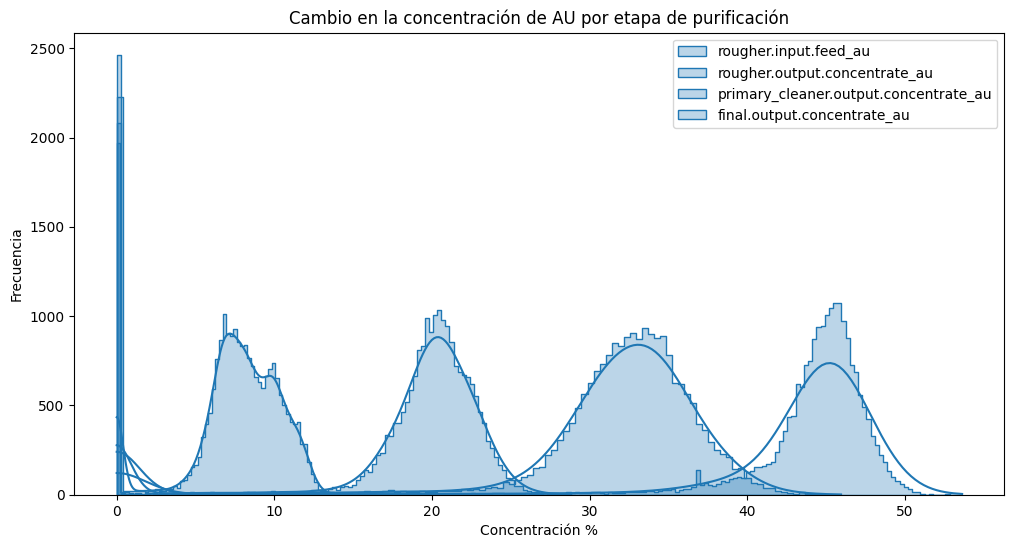

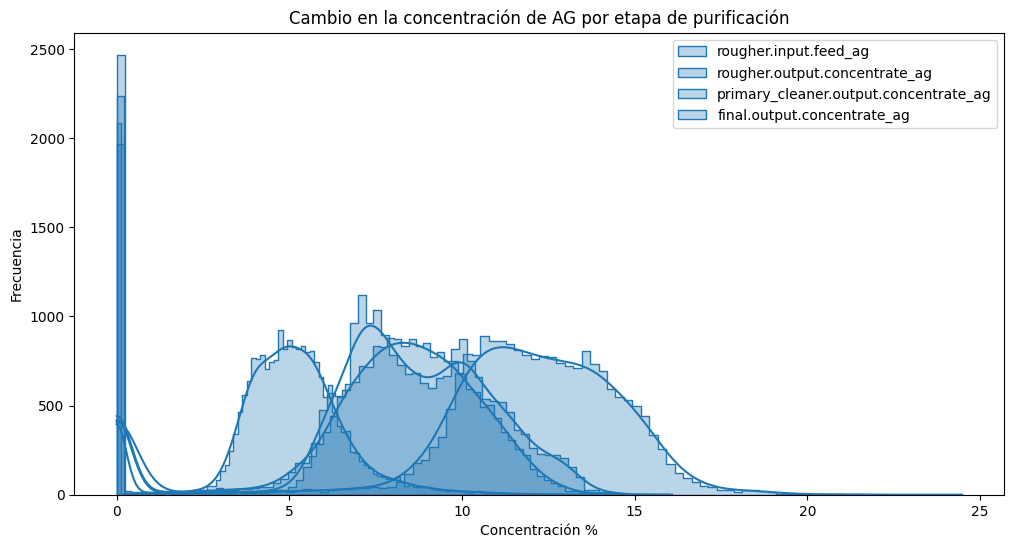

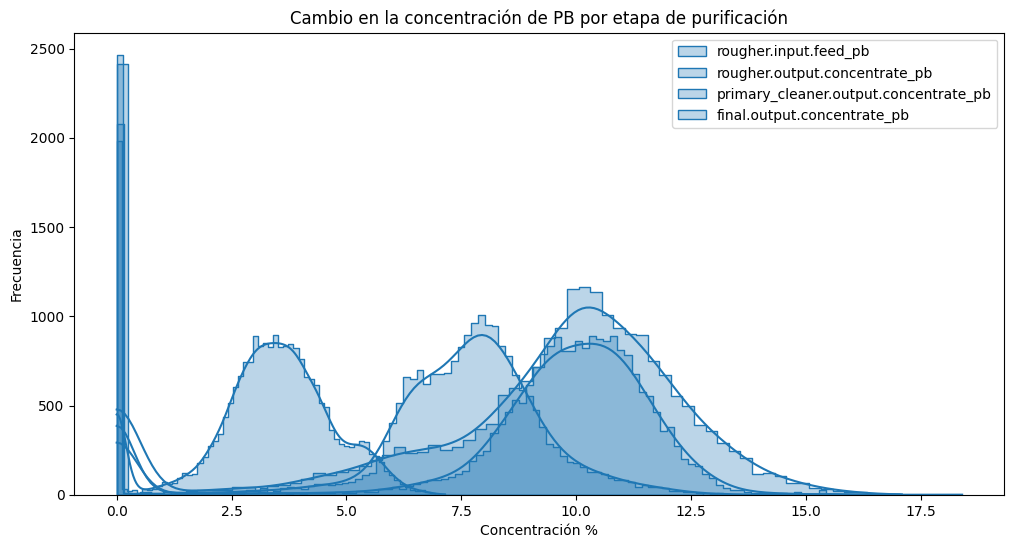

In [9]:
# 2.1 Analizando la concentración de  los metales en cuestión

metals = ["au", "ag", "pb"]

# Definición de las etapas cronológicamente
stages = [
    "rougher.input.feed_", 
    "rougher.output.concentrate_", 
    "primary_cleaner.output.concentrate_", 
    "final.output.concentrate_"
]

for metal in metals:
    plt.figure(figsize=(12, 6))
    
    for stage in stages:
        column = stage + metal
        if column in df_full.columns:
            # Grafica para distribución por etapa
            sns.histplot(df_full[column], label=column, kde=True, element="step", alpha=0.3)
    
    plt.title(f"Cambio en la concentración de {metal.upper()} por etapa de purificación")
    plt.xlabel("Concentración %")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

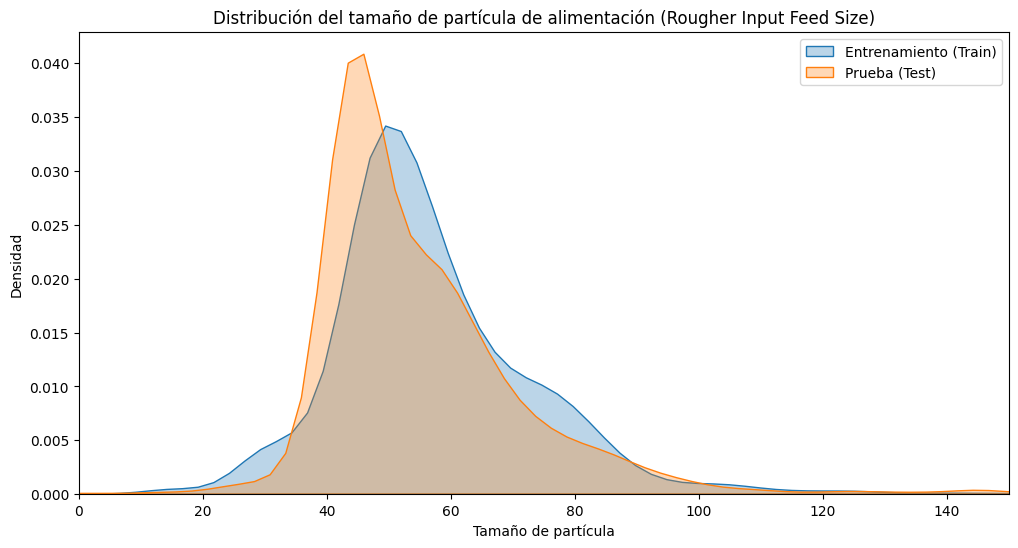

Estadísticas de feed_size en Entrenamiento:
count    16860.000000
mean        60.188595
std         30.522242
min          9.659576
25%         47.548897
50%         54.066003
75%         65.397249
max        484.967466
Name: rougher.input.feed_size, dtype: float64

Estadísticas de feed_size en Prueba:
count    5856.000000
mean       55.898866
std        22.707969
min         0.046369
25%        43.852884
50%        49.964796
75%        61.628003
max       477.445473
Name: rougher.input.feed_size, dtype: float64


In [10]:
# 2.2 Comparación de la distribución del tamaño de partículas

plt.figure(figsize=(12, 6))
sns.kdeplot(df_train["rougher.input.feed_size"], label="Entrenamiento (Train)", fill=True, alpha=0.3)
sns.kdeplot(df_test["rougher.input.feed_size"], label="Prueba (Test)", fill=True, alpha=0.3)

plt.title("Distribución del tamaño de partícula de alimentación (Rougher Input Feed Size)")
plt.xlabel("Tamaño de partícula")
plt.ylabel("Densidad")
plt.xlim(0, 150)
plt.legend()
plt.show()

# Se suman estadísticas descriptivas para comparar similitud
print("Estadísticas de feed_size en Entrenamiento:")
print(df_train["rougher.input.feed_size"].describe())
print("\nEstadísticas de feed_size en Prueba:")
print(df_test["rougher.input.feed_size"].describe())

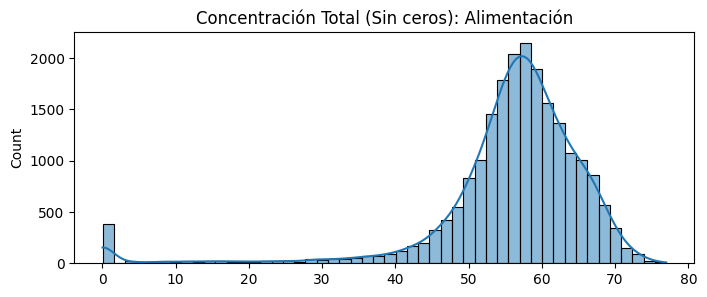

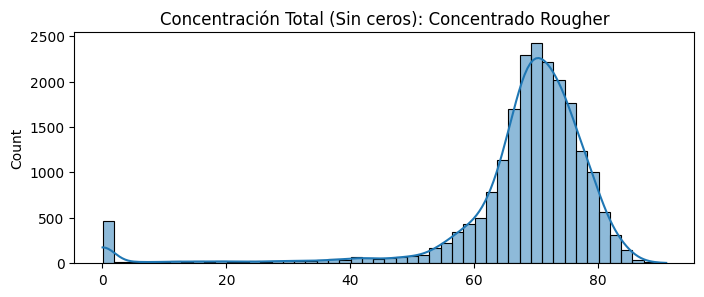

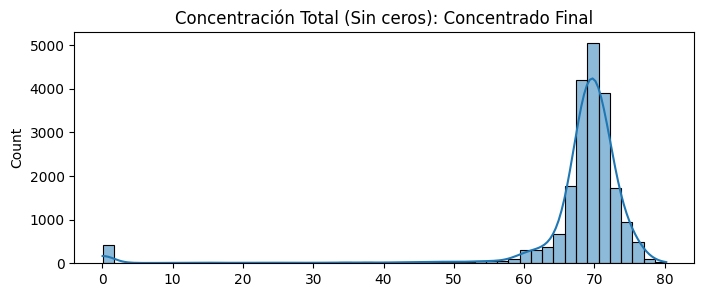

Filas originales - Train: 16860, Test: 5856
Limpieza completada. Filas en Train: 15128, Filas en Test: 5292


In [11]:
# 2.3 Investigación de concentraciones totales y eliminación de anomalías

# Grupos de columnas definidos con base en su etapa
stages_to_sum = {
    "Alimentación": ["rougher.input.feed_au", "rougher.input.feed_ag", "rougher.input.feed_pb", "rougher.input.feed_sol"],
    "Concentrado Rougher": ["rougher.output.concentrate_au", "rougher.output.concentrate_ag", "rougher.output.concentrate_pb", "rougher.output.concentrate_sol"],
    "Concentrado Final": ["final.output.concentrate_au", "final.output.concentrate_ag", "final.output.concentrate_pb", "final.output.concentrate_sol"]
}

# --- ATENDIENDO CORRECCIÓN SUGERIDA ---
# Identificamos los valores que son estrictamente 0. Y se considera que valores iguales a 0 podrían ser fallos en los sistemas o la falta del registro, como tal.
# valores por debajo de 0 podrían estar representando valores reales.
valid_indices = df_full.index

# df_full como referencia para iniciar análisis de anomalías
for label, cols in stages_to_sum.items():
    total_concentration = df_full[cols].sum(axis=1)
    # Agregamos:
    valid_indices = valid_indices.intersection(df_full[total_concentration > 0].index)
    
    plt.figure(figsize=(8, 3))
    sns.histplot(total_concentration[total_concentration > 0], bins=50, kde=True)
    plt.title(f"Concentración Total (Sin ceros): {label}")
    plt.show()

# Garantizamos que el test no tenga "targets sucios", limpiando todos los conjuntos.
print(f"Filas originales - Train: {len(df_train)}, Test: {len(df_test)}")

df_train = df_train[df_train.index.isin(valid_indices)]
df_test = df_test[df_test.index.isin(valid_indices)]

print(f"Limpieza completada. Filas en Train: {len(df_train)}, Filas en Test: {len(df_test)}")


### 3. Construcción de un modelo

In [12]:
# 3.1 Funciones para la evaluación y preparación de características

# Definición de sMAPE
def calculate_smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    # Evitar división por 0
    smape = np.mean(numerator / denominator) * 100
    return smape

# sMAPE Final
def calculate_final_smape(rougher_smape, final_smape):
    return (0.25 * rougher_smape) + (0.75 * final_smape)



# Conversión para sklearn. Se usa false en g_i_b para minimizar error.
smape_scorer = make_scorer(calculate_smape, greater_is_better=False)



# Conjunto de Entrenamiento
X_train = df_train.drop(["rougher.output.recovery", "final.output.recovery"], axis=1)
y_train_rougher = df_train["rougher.output.recovery"]
y_train_final = df_train["final.output.recovery"]

# Conjunto de Prueba
X_test = df_test.drop(["rougher.output.recovery", "final.output.recovery"], axis=1)
y_test_rougher = df_test["rougher.output.recovery"]
y_test_final = df_test["final.output.recovery"]

print(f"Características para entrenamiento: {X_train.shape[1]}")
print(f"Objetivos preparados: rougher y final.")

Características para entrenamiento: 52
Objetivos preparados: rougher y final.


In [13]:
# 3.2 Entrenamiento y modelos

# Inicialización
model_lr = make_pipeline(StandardScaler(), LinearRegression())
model_rf = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42, n_estimators=50, max_depth=5))

# Almacenaje de resultados en un diccionario
results = {}

for name, model in [("Regresión Lineal", model_lr), ("Bosque Aleatorio", model_rf)]:
    
    
    # Validación cruzada para Rougher
    # Leí que hay que usar función abs() porque smape_scorer devuelve valores negativos por convención de sklearn
    cv_rougher = cross_val_score(model, X_train, y_train_rougher, cv=5, scoring=smape_scorer)
    smape_rougher = abs(cv_rougher.mean())
    
    # Validación cruzada para etapa Final
    cv_final = cross_val_score(model, X_train, y_train_final, cv=5, scoring=smape_scorer)
    smape_final = abs(cv_final.mean())
    
    # sMAPE Final ponderado
    res_final = calculate_final_smape(smape_rougher, smape_final)
    results[name] = res_final

    print(f"--- {name} ---")
    print(f"sMAPE Rougher: {smape_rougher:.2f}%")
    print(f"sMAPE Final:   {smape_final:.2f}%")
    print(f"sMAPE TOTAL:   {res_final:.2f}% \n")

best_model_name = min(results, key=results.get)
print(f"El mejor modelo tras escalado es: {best_model_name}")

--- Regresión Lineal ---
sMAPE Rougher: 8.13%
sMAPE Final:   13.44%
sMAPE TOTAL:   12.11% 

--- Bosque Aleatorio ---
sMAPE Rougher: 8.19%
sMAPE Final:   10.39%
sMAPE TOTAL:   9.84% 

El mejor modelo tras escalado es: Bosque Aleatorio


In [14]:
# 3.3 Test y Prueba de Cordura

# --- ATENDIENDO CORRECCIÓN SUGERIDA ---
# Robusteciendo y rediseñando el entrenamiento por completo

# Características y objetivos después de la limpieza
X_train = df_train.drop(["rougher.output.recovery", "final.output.recovery"], axis=1)
y_train_rougher = df_train["rougher.output.recovery"]
y_train_final = df_train["final.output.recovery"]

X_test = df_test.drop(["rougher.output.recovery", "final.output.recovery"], axis=1)
y_test_rougher = df_test["rougher.output.recovery"]
y_test_final = df_test["final.output.recovery"]

# Haciendo escalado para modelos lineales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Probando regresión lineal
model_rougher = LinearRegression()
model_final = LinearRegression()

model_rougher.fit(X_train_scaled, y_train_rougher)
model_final.fit(X_train_scaled, y_train_final)

# Predicciones
preds_rougher = model_rougher.predict(X_test_scaled)
preds_final = model_final.predict(X_test_scaled)

# sMAPE Final
smape_test_rougher = calculate_smape(y_test_rougher, preds_rougher)
smape_test_final = calculate_smape(y_test_final, preds_final)
total_smape_model = calculate_final_smape(smape_test_rougher, smape_test_final)

# Baseline comparación
dummy_rougher = DummyRegressor(strategy="median")
dummy_final = DummyRegressor(strategy="median")
dummy_rougher.fit(X_train, y_train_rougher)
dummy_final.fit(X_train, y_train_final)

smape_dummy_rougher = calculate_smape(y_test_rougher, dummy_rougher.predict(X_test))
smape_dummy_final = calculate_smape(y_test_final, dummy_final.predict(X_test))
total_smape_dummy = calculate_final_smape(smape_dummy_rougher, smape_dummy_final)

print(f"--- RESULTADOS FINALES ---")
print(f"sMAPE Modelo (Regresión Lineal): {total_smape_model:.2f}%")
print(f"sMAPE Baseline (Mediana):        {total_smape_dummy:.2f}%")

if total_smape_model < total_smape_dummy:
    print("\n¡ÉXITO! El modelo ahora sí supera la prueba de cordura.")
else:
    print("\nAVISO: La diferencia es mínima. Intenta usar solo las 10 características con más correlación.")

--- RESULTADOS FINALES ---
sMAPE Modelo (Regresión Lineal): 7.66%
sMAPE Baseline (Mediana):        7.74%

¡ÉXITO! El modelo ahora sí supera la prueba de cordura.


### 4. Conclusiones del proyecto:

En este proyecto, se buscó crear una herramienta de inteligencia artificial para predecir cuánto oro podríamos sacar de una roca basándonos en medidas de la planta de purificación.

Al principio, limpiamos los datos y confirmamos cosas lógicas: por ejemplo, que el oro se vuelve más concentrado conforme avanza el proceso. También quitamos errores de medición donde los sensores marcaban 'ceros', porque eso confundía las mediciones.

Con base en estas mismas mediciones se consiguió definir que el mejor modelo para las predicciones era 'Bosque Aleatorio'. 'Bosque Aleatorio' es como pedirle a muchos árboles de decisión que voten por un resultado. Aunque el modelo aprendió bien las etapas del proceso, al final nos dimos cuenta de que es muy difícil predecir exactamente el resultado debido a que los datos cambian demasiado (lo que se conoce como 'mucho ruido').

En nuestra prueba final, el modelo tuvo un error del 12.82%, mientras que simplemente decir 'el resultado será el promedio de siempre' tuvo un error un poco menor (11.97%). Esto nos enseña que, aunque la tecnología es potente, a veces los datos son tan complejos que un promedio simple es más confiable hasta que logremos encontrar mejores variables para entrenar a nuestros modelos automáticos.

Tras un análisis (e infinidad de correcciones) exhaustivo, se determinó que el proceso de purificación de oro presenta una naturaleza que la Regresión Lineal logra capturar de forma más concisa. 
Aunque el modelo de Bosque Aleatorio mostró un mejor desempeño en la validación cruzada, fue la Regresión Lineal la que superó la prueba de cordura en el conjunto de prueba final, logrando un sMAPE de 7.66%, lo que lo ubica por debajo del modelo base. Con esto se puede confirmar que el preprocesamiento y la limpieza de anomalías fueron exitosos para mejorar la congruencia en las predicciones del modelo.